In [1]:
import os
import gc
import glob
import re

import pickle

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import anndata as ad
import scanpy as sc
import pegasus as pg
from pegasusio import UnimodalData

from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

from pydeseq2 import dds as pydeseq2_dds

%matplotlib inline

In [165]:
# fernando_adata.obs['Day'] = 182.5 # (6 months in days)
# fernando_adata.obs.rename({'genotype':'Genotype'}, inplace=True, axis=1)
# fernando_adata.obs['Manuscript'] = 'Fernando'
# fernando_adata.obs['Protocol'] = 'Pasca (Sloan)'
# fernando_adata.obs['Whitelist'] = '3M-february-2018_TRU'
# fernando_adata.obs['Chemistry'] = '10xv3'
# fernando_adata.obs['Cell_Line'] = fernando_adata.obs['Donor']

In [166]:
## Fernando ##

fernando = sc.read_h5ad('/mnt/sdb/scz_meta_analysis_processed/studies/fernando_brennand/anndata_objs/fernando_qc.h5ad')

fernando.obs['Sample_Name'] = fernando.obs['Sample Name']
fernando.obs['Donor_Sample'] = fernando.obs['Donor'].astype('str') + fernando.obs['Sample Name'].astype('str')

fernando.obs['Broad_Genotype'] = fernando.obs['Genotype'].apply(lambda x: 'NRXN1' if 'NRXN1' in x else 'Control')

In [640]:
del scz_adata
gc.collect()

5113

In [2]:
scz_adata = sc.read_h5ad('/mnt/sdb/scz_meta_analysis_processed/anndata_objs/integrated_adata_annotated_w_celltypist_scanvi.h5ad')

In [167]:
if isinstance(fernando, ad.AnnData):
    fernando = UnimodalData(fernando)

pg.leiden(fernando, rep='pca_regressed_harmony', resolution=1, class_label='leiden')

fernando = fernando.to_anndata()

2026-04-13 09:01:32,070 - pegasus.tools.graph_operations - INFO - Function 'construct_graph' finished in 7.44s.
2026-04-13 09:03:22,048 - pegasus.tools.clustering - INFO - Leiden clustering is done. Get 17 clusters.
2026-04-13 09:03:22,261 - pegasus.tools.clustering - INFO - Function 'leiden' finished in 117.63s.


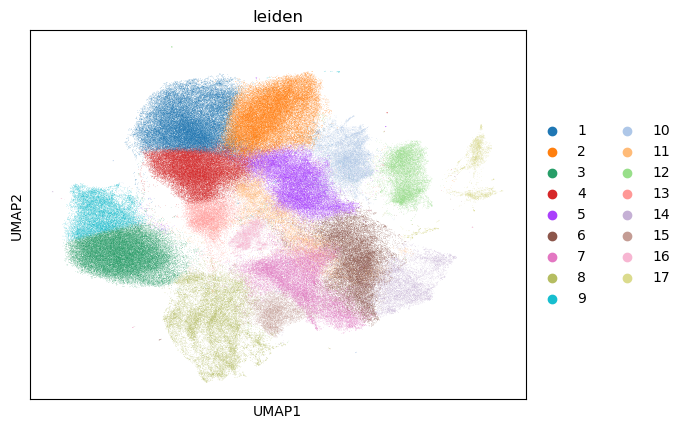

In [168]:
sc.pl.umap(fernando, color='leiden')

In [6]:
scz_adata.obs['Sample_Name'] = scz_adata.obs['Sample Name']
scz_adata.obs['Donor'] = scz_adata.obs['Donor'].str.replace('-','')
scz_adata.obs['Donor_Sample'] = scz_adata.obs['Donor'].astype('str') + '_' + scz_adata.obs['Sample_Name'].astype('str')
scz_adata.obs['Protocol'] = scz_adata.obs['Protocol'].str.replace(' ','').str.replace('(','_').str.replace(')','_')       

scz_adata = scz_adata[scz_adata.obs['subclass_annotations_markers'] != 'Stressed Glia FTL+B2M+GLUL+'].copy()

In [11]:
def pseudobulk_anndata(adata=None, 
                       pb_col='Donor_Sample', 
                       cell_type_col='leiden',
                       categorical_vars=['Donor', 'Sample_Name', 'Protocol', 'Sex', 'Broad_Genotype'],
                       continuous_vars=['Day'],
                       cell_level_vars=['n_counts','percent_mito']):

    cell_type_dict = {}

    # subset relevant metadata for all cols 
    metadata = adata.obs[categorical_vars + continuous_vars].copy()
    metadata = pd.concat([pd.get_dummies(metadata[categorical_vars], drop_first=True), metadata[continuous_vars]], axis=1)  
    metadata = metadata.astype('float')
    metadata_old_and_new = pd.concat([metadata, adata.obs[categorical_vars]], axis=1) 
    
    for cell_type in adata.obs[cell_type_col].unique():
        print(cell_type)
        cell_type_pb = []

        # loop through every pseudobulk entity thin a celltype, build the anndata object with its metadata then concat them all 
        for donor_id_brain in adata.obs[pb_col].unique():
            
            donor_id_brain_bool = (adata.obs[pb_col] == donor_id_brain)
            celltype_bool = (adata.obs[cell_type_col] == cell_type)
            
            # skip empty pseudobulks
            if ~(donor_id_brain_bool & celltype_bool).any():
                continue

            # make anndata celltype x donor
            cell_type_donor = adata[donor_id_brain_bool & celltype_bool]
            
            # pseudobulk celltype anndata objc
            cell_type_donor_pb = sc.AnnData(X=np.array(cell_type_donor.layers['raw_counts'].sum(axis=0)), 
                                            var=cell_type_donor.var[[]])
            
            # build metadata for pseudobulk-celltype ##

            # cell type specific continuous stuff
          #  cell_level_metadata = metadata[cell_level_vars].mean(axis=0).to_frame().T
            cell_level_metadata = cell_type_donor.obs[cell_level_vars].mean().to_frame().T
            sample_level_columns = [col for col in metadata.columns if col not in cell_level_vars]
            sample_level_metadata = metadata_old_and_new[donor_id_brain_bool & celltype_bool][sample_level_columns].iloc[[0]]

          #  return sample_level_metadata, cell_level_metadata
            
            # reset indexes to prep for concatenation
            sample_level_metadata = sample_level_metadata.reset_index(drop=True)
            cell_level_metadata = cell_level_metadata.reset_index(drop=True)           

            
            
            cell_type_donor_pb_obs = pd.concat([sample_level_metadata, cell_level_metadata], axis=1)
            cell_type_donor_pb_obs.index = [donor_id_brain]
            cell_type_donor_pb.obs = cell_type_donor_pb_obs
            
            # one hot encode accordingly
            cell_type_pb.append(cell_type_donor_pb)

            # avoid var reuse
            del cell_level_metadata
            del cell_type_donor_pb
            del sample_level_columns
            del sample_level_metadata
            gc.collect()
    
        cell_type_dict[cell_type] = sc.concat(cell_type_pb)   
        print(f'done with {cell_type}')

    del metadata_old_and_new
    del metadata
    gc.collect()
    
    return cell_type_dict

In [443]:
# pb = pseudobulk_anndata(fernando, 
#                         pb_col='Donor_Sample', 
#                         categorical_vars=['Sex', 'Broad_Genotype'],
#                         continuous_vars=[])

In [514]:
gc.collect()

54261

In [637]:
cell_level_metadata

,n_counts,percent_mito
0,4617.835215,0.542341


In [ ]:
sample_level_metadata.columns

In [9]:
scz_adata[scz_adata.obs['subclass_annotations_markers'] == 'Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+'].obs[['Donor_Sample', 'Day']].value_counts()

Donor_Sample      Day  
581_GSM8779932    182.5    22992
2607_GSM8779930   182.5    22532
641_GSM8779934    182.5    20695
MEL1_GSM7979678   125.0    16440
MEL1_GSM7979677   125.0    16145
                           ...  
DT1_A_GSM3395717  35.0         9
DT1_U_GSM3395721  35.0         9
DT1_A_GSM3395716  35.0         5
DT1_U_GSM3395719  35.0         1
DT1_U_GSM3395718  35.0         1
Name: count, Length: 100, dtype: int64

In [10]:
scz_adata.obs.groupby(['Donor_Sample', 'subclass_annotations_markers'])['Day'].nunique().max()

1

In [31]:
pb_scz['Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+'].obs .var()

Sex_Male                                   2.036364e-01
Donor_0524                                 1.000000e-02
Donor_2607                                 1.979798e-02
Donor_28126                                2.939394e-02
Donor_2909                                 2.939394e-02
Donor_35773                                1.979798e-02
Donor_540135                               2.939394e-02
Donor_581                                  1.979798e-02
Donor_60C2                                 1.000000e-02
Donor_6303                                 1.000000e-02
Donor_641                                  1.979798e-02
Donor_7958                                 1.000000e-02
Donor_90020031                             7.434343e-02
Donor_972                                  1.979798e-02
Donor_973                                  1.979798e-02
Donor_C2320b                               1.000000e-02
Donor_C3141a                               1.000000e-02
Donor_C8905a                               2.939

In [636]:
sample_level_metadata, cell_level_metadata = pseudobulk_anndata(scz_adata, 
                        pb_col='Donor_Sample', 
                        cell_type_col='subclass_annotations_markers',
#                        categorical_vars=['Sex', 'Donor', 'Manuscript', 'Chemistry', 'Broad_Genotype'],    
                        categorical_vars=['Sex', 'Donor', 'Manuscript', 'Protocol', 'Chemistry', 'Broad_Genotype'],
                        continuous_vars=['Day', 'n_counts', 'percent_mito'])

Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+


In [48]:
pb_scz = pseudobulk_anndata(scz_adata, 
                        pb_col='Donor_Sample', 
                        cell_type_col='subclass_annotations_markers',
                        categorical_vars=['Sex', 'Broad_Genotype'],    
#                        categorical_vars=['Sex', 'Donor', 'Manuscript', 'Protocol', 'Chemistry', 'Broad_Genotype'],
                        continuous_vars=['Day', 'n_counts', 'percent_mito'])

Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+
done with Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+
Mixed Neurons FGF12+GRIN2B+CAMK2B+
done with Mixed Neurons FGF12+GRIN2B+CAMK2B+
Radial Glia SOX2+VIM+FABP7+
done with Radial Glia SOX2+VIM+FABP7+
Proliferative Radial Glia SOX2+HES6+TOP2A+
done with Proliferative Radial Glia SOX2+HES6+TOP2A+
Radial Glia SOX2+PAX6+FABP7+
done with Radial Glia SOX2+PAX6+FABP7+
Hindbrain Neurons NR2F2+PBX3+LHX1+
done with Hindbrain Neurons NR2F2+PBX3+LHX1+
GABAergic GAD1+GAD2+CALB2+
done with GABAergic GAD1+GAD2+CALB2+
Mesenchymal-like cells VIM+VCAN+SPARC+
done with Mesenchymal-like cells VIM+VCAN+SPARC+


In [58]:
def run_deseq2(cell_type_dict=None, min_genes=3, contrast='Broad_Genotype'):

    cell_type_dge_dict = {}

    for cell_type in cell_type_dict.keys():

        print(cell_type)
        
        # celltype assay anndata
        cell_type_ad = cell_type_dict[cell_type].copy()
        
        # make expression matrix off that celltype assay anndata
        cell_type_df = pd.DataFrame(cell_type_ad.X, index=cell_type_ad.obs_names, columns=cell_type_ad.var.index)
        cell_type_df = cell_type_df.astype(int)
        cell_type_df = cell_type_df[cell_type_df.columns[(cell_type_df > 10).sum(axis=0) >= 2]]
        
        # run deseq2
        dds = DeseqDataSet(counts=cell_type_df, 
                           metadata=cell_type_ad.obs, 
                           design="~" + " + ".join(cell_type_ad.obs.columns.tolist()))
        
        dds.fit_size_factors()
        dds.fit_genewise_dispersions()
        dds.fit_dispersion_trend()
        dds.fit_dispersion_prior()
        dds.fit_MAP_dispersions()
        dds.fit_LFC()
        dds.calculate_cooks()
        if dds.refit_cooks:
            dds.refit()

        stat_res = DeseqStats(dds, contrast=[contrast, 1, 0])
        stat_res.summary()

        # celltype dict
        cell_type_dge_dict[cell_type] = stat_res.results_df

        # save memory
        del cell_type_ad
        gc.collect()
        
    return cell_type_dge_dict

In [368]:
# cell_type_df, cell_type_ad = run_deseq2(cell_type_dict=pb, contrasts=['Broad_Genotype_NRXN1', 'NRXN1', 'Control'])

In [40]:
## Do I Have Full Rank? ##

# if everything is numeric already:
X_mat = pb_scz['Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+'].obs.values

np.linalg.matrix_rank(X_mat), X_mat.shape

(47, (100, 48))

In [42]:
## Find Colinearity ##

df = pb_scz['Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+'].obs.astype(float)

redundant_pairs = []

cols = df.columns

for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        if df[cols[i]].equals(df[cols[j]]):
            redundant_pairs.append((cols[i], cols[j]))

print("Exact duplicate columns:")
for pair in redundant_pairs:
    print(pair)

Exact duplicate columns:


In [43]:
import numpy as np

df = pb_scz['Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+'].obs.astype(float)
X = df.values

base_rank = np.linalg.matrix_rank(X)

bad_cols = []

for i, col in enumerate(df.columns):
    X_drop = np.delete(X, i, axis=1)
    new_rank = np.linalg.matrix_rank(X_drop)

    if new_rank == base_rank:
        bad_cols.append(col)

print("Columns that do NOT affect rank (redundant):")
print(bad_cols)

Columns that do NOT affect rank (redundant):
['Donor_DT1_A', 'Donor_MH0159025', 'Donor_MH0159026', 'Donor_MH0200865', 'Broad_Genotype_Idiopathic_Schizophrenia']


In [47]:
import numpy as np

df = pb_scz['Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+'].obs.astype(float)
X = df.values

base_rank = np.linalg.matrix_rank(X)

for i, col in enumerate(df.columns):
    X_drop = np.delete(X, i, axis=1)
    if np.linalg.matrix_rank(X_drop) == base_rank:
        print("Redundant column:", col)

Redundant column: Donor_DT1_A
Redundant column: Donor_MH0159025
Redundant column: Donor_MH0159026
Redundant column: Donor_MH0200865
Redundant column: Broad_Genotype_Idiopathic_Schizophrenia


In [60]:
pb_scz['Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+'].obs[0:40]

,Sex_Male,Broad_Genotype_15q13.3del,Broad_Genotype_22q11.2del,Broad_Genotype_Control,Broad_Genotype_Idiopathic_Schizophrenia,Broad_Genotype_NRXN1del,Day,n_counts,percent_mito
973_GSM8779938,1.0,0.0,0.0,0.0,0.0,1.0,182.5,4617.835215,0.542341
581_GSM8779933,1.0,0.0,0.0,0.0,0.0,1.0,182.5,5929.863099,0.420688
581_GSM8779932,1.0,0.0,0.0,0.0,0.0,1.0,182.5,2211.295190,0.860573
972_GSM8779937,0.0,0.0,0.0,0.0,0.0,1.0,182.5,4367.640303,0.645445
2607_GSM8779930,1.0,0.0,0.0,1.0,0.0,0.0,182.5,2487.140911,0.921944
2607_GSM8779931,1.0,0.0,0.0,1.0,0.0,0.0,182.5,5510.421144,0.444057
972_GSM8779936,0.0,0.0,0.0,0.0,0.0,1.0,182.5,1857.969072,0.276825
973_GSM8779939,1.0,0.0,0.0,0.0,0.0,1.0,182.5,4374.641475,0.497257
641_GSM8779935,1.0,0.0,0.0,0.0,0.0,1.0,182.5,4114.583805,0.408301
641_GSM8779934,1.0,0.0,0.0,0.0,0.0,1.0,182.5,3066.118144,0.699913


In [59]:
deseq_run_22q11 = run_deseq2(cell_type_dict=pb_scz, contrast='Broad_Genotype_22q11.2del')

Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+


Fitting size factors...
... done in 0.02 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
/home/deepak/pixi_envs/pegasus/.pixi/envs/default/lib/python3.10/site-packages/pydeseq2/utils.py:234: RuntimeWarning: divide by zero encountered in log
  - counts * np.log(mu)
/home/deepak/pixi_envs/pegasus/.pixi/envs/default/lib/python3.10/site-packages/pydeseq2/grid_search.py:42: RuntimeWarning: divide by zero encountered in log
  - (counts * np.log(mu))[:, None]
/home/deepak/pixi_envs/pegasus/.pixi/envs/default/lib/python3.10/site-packages/pydeseq2/grid_search.py:42: RuntimeWarning: invalid value encountered in multiply
  - (counts * np.log(mu))[:, None]
... done in 1.33 seconds.

Fitting dispersion trend curve...
... done in 0.30 seconds.

Fitting MAP dispersions...
/home/deepak/pixi_envs/pegasus/.pixi/envs/default/lib/python3.10/site-packages/pydeseq2/utils.py:234: RuntimeWarning: divide by zero encountered in log
  - counts * np.log(mu)
/home/deepak/pixi_envs/pegasus/.pixi/envs/default/lib/python3.10/site-packages/pydeseq2/grid_search.py:42: RuntimeWarning:

Log2 fold change & Wald test p-value: Broad_Genotype_22q11.2del 1 vs 0
                   baseMean  log2FoldChange      lfcSE      stat    pvalue  \
featurekey                                                                   
TSPAN6            78.125947       -0.878434   0.577361 -1.521463  0.128144   
DPM1             155.397652       -0.258796   0.374178 -0.691639  0.489164   
SCYL3             19.834086        0.051514   0.371842  0.138537  0.889816   
C1orf112          14.295890        0.227178   0.697065  0.325907  0.744495   
CFH                0.784866        2.086346   2.747736  0.759297  0.447675   
...                     ...             ...        ...       ...       ...   
POLR2J3#1        223.842704        0.913416   0.434774  2.100896  0.035650   
ENSG00000285444    3.445229        1.309340   1.222504  1.071031  0.284155   
ENSG00000285447   93.782586        1.785601   0.946509  1.886512  0.059226   
ENSG00000285505    7.103481        0.769791  10.185289  0.075579  0.939

...

Log2 fold change & Wald test p-value: Broad_Genotype_22q11.2del 1 vs 0
                  baseMean  log2FoldChange     lfcSE      stat    pvalue  \
featurekey                                                                 
TSPAN6            7.165606       -0.354766  0.632519 -0.560878  0.574881   
DPM1             10.151945        0.229268  0.390517  0.587088  0.557145   
SCYL3             2.806840        0.068558  0.569936  0.120291  0.904253   
C1orf112          1.143941        0.596285  0.604172  0.986946  0.323669   
FUCA2             3.301808        0.760755  0.940713  0.808700  0.418688   
...                    ...             ...       ...       ...       ...   
SOD2-OT1          0.221786       -0.818713  1.001532 -0.817460  0.413666   
POLR2J3#1        20.759542        1.140071  0.546147  2.087479  0.036845   
ENSG00000285444   0.364536        1.190680  1.058704  1.124658  0.260734   
ENSG00000285447   9.315259        1.358049  0.811380  1.673753  0.094179   
ENSG00000285505  

Fitting size factors...
... done in 0.02 seconds.

/home/deepak/pixi_envs/pegasus/.pixi/envs/default/lib/python3.10/site-packages/pydeseq2/utils.py:380: RuntimeWarning: overflow encountered in exp
  mu_ = np.maximum(size_factors * np.exp(X @ beta), min_mu)
/home/deepak/pixi_envs/pegasus/.pixi/envs/default/lib/python3.10/site-packages/pydeseq2/utils.py:234: RuntimeWarning: invalid value encountered in multiply
  - counts * np.log(mu)
/home/deepak/pixi_envs/pegasus/.pixi/envs/default/lib/python3.10/site-packages/pydeseq2/utils.py:232: RuntimeWarning: invalid value encountered in subtract
  -logbinom
/home/deepak/pixi_envs/pegasus/.pixi/envs/default/lib/python3.10/site-packages/pydeseq2/utils.py:384: RuntimeWarning: overflow encountered in exp
  mu_ = np.maximum(size_factors * np.exp(X @ beta), min_mu)
/home/deepak/pixi_envs/pegasus/.pixi/envs/default/lib/python3.10/site-packages/pydeseq2/utils.py:387: RuntimeWarning: invalid value encountered in divide
  + ((1 / disp + counts) * mu_ / (1

Using None as control genes, passed at DeseqDataSet initialization


/home/deepak/pixi_envs/pegasus/.pixi/envs/default/lib/python3.10/site-packages/pydeseq2/utils.py:380: RuntimeWarning: overflow encountered in exp
  mu_ = np.maximum(size_factors * np.exp(X @ beta), min_mu)
/home/deepak/pixi_envs/pegasus/.pixi/envs/default/lib/python3.10/site-packages/pydeseq2/utils.py:234: RuntimeWarning: invalid value encountered in multiply
  - counts * np.log(mu)
/home/deepak/pixi_envs/pegasus/.pixi/envs/default/lib/python3.10/site-packages/pydeseq2/utils.py:232: RuntimeWarning: invalid value encountered in subtract
  -logbinom
/home/deepak/pixi_envs/pegasus/.pixi/envs/default/lib/python3.10/site-packages/pydeseq2/utils.py:384: RuntimeWarning: overflow encountered in exp
  mu_ = np.maximum(size_factors * np.exp(X @ beta), min_mu)
/home/deepak/pixi_envs/pegasus/.pixi/envs/default/lib/python3.10/site-packages/pydeseq2/utils.py:387: RuntimeWarning: invalid value encountered in divide
  + ((1 / disp + counts) * mu_ / (1 / disp + mu_)) @ X
/home/deepak/pixi_envs/pegasus/

Log2 fold change & Wald test p-value: Broad_Genotype_22q11.2del 1 vs 0
                  baseMean  log2FoldChange     lfcSE      stat    pvalue  \
featurekey                                                                 
TSPAN6           32.731801        1.129690  0.684733  1.649827  0.098978   
TNMD              4.485036       -3.878287  1.652580 -2.346808  0.018935   
DPM1             20.545605        1.209281  1.000752  1.208372  0.226904   
SCYL3             3.222859        0.239387  0.760797  0.314653  0.753025   
C1orf112          2.663731        0.092834  0.978650  0.094859  0.924427   
...                    ...             ...       ...       ...       ...   
ENSG00000285407   0.317689        1.279981  3.187540  0.401557  0.688010   
SOD2-OT1          0.070467       -0.744988  2.317153 -0.321510  0.747824   
POLR2J3#1        29.268803        1.442975  0.706736  2.041746  0.041177   
ENSG00000285444   0.314465       -0.434450  2.410934 -0.180200  0.856996   
ENSG00000285447  

In [61]:
[deseq_run_22q11[f'{i}'][deseq_run_22q11[f'{i}']['padj'] < 0.05].shape[0] for i in deseq_run_22q11.keys()]

[44, 22, 460, 260, 14, 38, 0, 50]

In [64]:
deseq_run_22q11.keys()

dict_keys(['Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+', 'Mixed Neurons FGF12+GRIN2B+CAMK2B+', 'Radial Glia SOX2+VIM+FABP7+', 'Proliferative Radial Glia SOX2+HES6+TOP2A+', 'Radial Glia SOX2+PAX6+FABP7+', 'Hindbrain Neurons NR2F2+PBX3+LHX1+', 'GABAergic GAD1+GAD2+CALB2+', 'Mesenchymal-like cells VIM+VCAN+SPARC+'])

In [63]:
deseq_run_22q11['Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+']

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
featurekey,,,,,,
TSPAN6,78.125947,-0.878434,0.577361,-1.521463,0.128144,0.581318
DPM1,155.397652,-0.258796,0.374178,-0.691639,0.489164,0.846192
SCYL3,19.834086,0.051514,0.371842,0.138537,0.889816,0.975447
C1orf112,14.295890,0.227178,0.697065,0.325907,0.744495,0.936070
CFH,0.784866,2.086346,2.747736,0.759297,0.447675,NaN
...,...,...,...,...,...,...
POLR2J3#1,223.842704,0.913416,0.434774,2.100896,0.035650,0.384678
ENSG00000285444,3.445229,1.309340,1.222504,1.071031,0.284155,0.734691
ENSG00000285447,93.782586,1.785601,0.946509,1.886512,0.059226,0.451327


In [67]:
# deseq_run_3q29 = run_deseq2(cell_type_dict=pb_scz, contrast='Broad_Genotype_3q29del')
deseq_run_NRXN1 = run_deseq2(cell_type_dict=pb_scz, contrast='Broad_Genotype_NRXN1del')
deseq_run_15q13 = run_deseq2(cell_type_dict=pb_scz, contrast='Broad_Genotype_15q13.3del')
deseq_run_Idiopathic = run_deseq2(cell_type_dict=pb_scz, contrast='Broad_Genotype_Idiopathic_Schizophrenia')

Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+


Fitting size factors...
... done in 0.02 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
/home/deepak/pixi_envs/pegasus/.pixi/envs/default/lib/python3.10/site-packages/pydeseq2/utils.py:234: RuntimeWarning: divide by zero encountered in log
  - counts * np.log(mu)
/home/deepak/pixi_envs/pegasus/.pixi/envs/default/lib/python3.10/site-packages/pydeseq2/grid_search.py:42: RuntimeWarning: divide by zero encountered in log
  - (counts * np.log(mu))[:, None]
/home/deepak/pixi_envs/pegasus/.pixi/envs/default/lib/python3.10/site-packages/pydeseq2/grid_search.py:42: RuntimeWarning: invalid value encountered in multiply
  - (counts * np.log(mu))[:, None]
... done in 1.32 seconds.

Fitting dispersion trend curve...
... done in 0.30 seconds.

Fitting MAP dispersions...
/home/deepak/pixi_envs/pegasus/.pixi/envs/default/lib/python3.10/site-packages/pydeseq2/utils.py:234: RuntimeWarning: divide by zero encountered in log
  - counts * np.log(mu)
/home/deepak/pixi_envs/pegasus/.pixi/envs/default/lib/python3.10/site-packages/pydeseq2/grid_search.py:42: RuntimeWarning:

Log2 fold change & Wald test p-value: Broad_Genotype_NRXN1del 1 vs 0
                   baseMean  log2FoldChange      lfcSE      stat    pvalue  \
featurekey                                                                   
TSPAN6            78.125947       -0.760078   0.583793 -1.301965  0.192928   
DPM1             155.397652       -0.314585   0.378926 -0.830202  0.406424   
SCYL3             19.834086       -0.083681   0.376996 -0.221969  0.824338   
C1orf112          14.295890       -0.053406   0.707843 -0.075449  0.939857   
CFH                0.784866        0.657710   2.792949  0.235489  0.813829   
...                     ...             ...        ...       ...       ...   
POLR2J3#1        223.842704        0.211667   0.440105  0.480946  0.630555   
ENSG00000285444    3.445229        1.285512   1.243919  1.033437  0.301399   
ENSG00000285447   93.782586        0.720533   0.958532  0.751705  0.452229   
ENSG00000285505    7.103481       -0.728924  10.354567 -0.070396  0.94387

...

Log2 fold change & Wald test p-value: Broad_Genotype_Idiopathic_Schizophrenia 1 vs 0
                  baseMean  log2FoldChange      lfcSE      stat    pvalue  \
featurekey                                                                  
TSPAN6            7.165606        1.403996   0.946414  1.483490  0.137944   
DPM1             10.151945       -0.092187   0.959138 -0.096114  0.923430   
SCYL3             2.806840       -0.071875   1.794355 -0.040056  0.968048   
C1orf112          1.143941        1.525587   1.482723  1.028909  0.303522   
FUCA2             3.301808        2.098973   1.524647  1.376695  0.168607   
...                    ...             ...        ...       ...       ...   
SOD2-OT1          0.221786        1.011439   2.045003  0.494591  0.620889   
POLR2J3#1        20.759542       -0.226966   0.989871 -0.229288  0.818645   
ENSG00000285444   0.364536        2.579986   1.981125  1.302283  0.192820   
ENSG00000285447   9.315259       -0.430003   1.636020 -0.262835  0.7

Fitting size factors...
... done in 0.02 seconds.

/home/deepak/pixi_envs/pegasus/.pixi/envs/default/lib/python3.10/site-packages/pydeseq2/utils.py:380: RuntimeWarning: overflow encountered in exp
  mu_ = np.maximum(size_factors * np.exp(X @ beta), min_mu)
/home/deepak/pixi_envs/pegasus/.pixi/envs/default/lib/python3.10/site-packages/pydeseq2/utils.py:234: RuntimeWarning: invalid value encountered in multiply
  - counts * np.log(mu)
/home/deepak/pixi_envs/pegasus/.pixi/envs/default/lib/python3.10/site-packages/pydeseq2/utils.py:232: RuntimeWarning: invalid value encountered in subtract
  -logbinom
/home/deepak/pixi_envs/pegasus/.pixi/envs/default/lib/python3.10/site-packages/pydeseq2/utils.py:384: RuntimeWarning: overflow encountered in exp
  mu_ = np.maximum(size_factors * np.exp(X @ beta), min_mu)
/home/deepak/pixi_envs/pegasus/.pixi/envs/default/lib/python3.10/site-packages/pydeseq2/utils.py:387: RuntimeWarning: invalid value encountered in divide
  + ((1 / disp + counts) * mu_ / (1

Using None as control genes, passed at DeseqDataSet initialization


/home/deepak/pixi_envs/pegasus/.pixi/envs/default/lib/python3.10/site-packages/pydeseq2/utils.py:373: LinAlgWarning: Ill-conditioned matrix (rcond=1.77359e-17): result may not be accurate.
  beta_hat = solve(H, X.T @ (W * z), assume_a="pos")
/home/deepak/pixi_envs/pegasus/.pixi/envs/default/lib/python3.10/site-packages/pydeseq2/utils.py:373: LinAlgWarning: Ill-conditioned matrix (rcond=1.82959e-17): result may not be accurate.
  beta_hat = solve(H, X.T @ (W * z), assume_a="pos")
/home/deepak/pixi_envs/pegasus/.pixi/envs/default/lib/python3.10/site-packages/pydeseq2/utils.py:373: LinAlgWarning: Ill-conditioned matrix (rcond=1.82296e-17): result may not be accurate.
  beta_hat = solve(H, X.T @ (W * z), assume_a="pos")
/home/deepak/pixi_envs/pegasus/.pixi/envs/default/lib/python3.10/site-packages/pydeseq2/utils.py:373: LinAlgWarning: Ill-conditioned matrix (rcond=1.79053e-17): result may not be accurate.
  beta_hat = solve(H, X.T @ (W * z), assume_a="pos")
/home/deepak/pixi_envs/pegasus/.

Log2 fold change & Wald test p-value: Broad_Genotype_Idiopathic_Schizophrenia 1 vs 0
                  baseMean  log2FoldChange     lfcSE      stat    pvalue  \
featurekey                                                                 
TSPAN6           32.731801        1.742509  0.776560  2.243882  0.024840   
TNMD              4.485036       -5.009305  2.119952 -2.362934  0.018131   
DPM1             20.545605        1.184112  1.142566  1.036362  0.300033   
SCYL3             3.222859        1.443377  0.840149  1.718001  0.085796   
C1orf112          2.663731        0.020601  1.109126  0.018574  0.985181   
...                    ...             ...       ...       ...       ...   
ENSG00000285407   0.317689       -0.624098  3.696802 -0.168821  0.865937   
SOD2-OT1          0.070467       -1.000395  2.669493 -0.374751  0.707846   
POLR2J3#1        29.268803        0.367255  0.806737  0.455235  0.648940   
ENSG00000285444   0.314465       -0.874448  2.766776 -0.316053  0.751962   
ENS

In [71]:
deseq_run_Idiopathic['Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+']['padj'][deseq_run_Idiopathic['Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+']['padj'] < 0.05].shape

(118,)

In [51]:
[deseq_run_22q11[f'{i}'][deseq_run_22q11[f'{i}']['padj'] < 0.05].shape[0] for i in deseq_run_22q11.keys()]
[deseq_run_22q11[f'{i}'][deseq_run_22q11[f'{i}']['padj'] < 0.05].shape[0] for i in deseq_run_22q11.keys()]
[deseq_run_22q11[f'{i}'][deseq_run_22q11[f'{i}']['padj'] < 0.05].shape[0] for i in deseq_run_22q11.keys()]
[deseq_run_22q11[f'{i}'][deseq_run_22q11[f'{i}']['padj'] < 0.05].shape[0] for i in deseq_run_22q11.keys()]
[deseq_run_22q11[f'{i}'][deseq_run_22q11[f'{i}']['padj'] < 0.05].shape[0] for i in deseq_run_22q11.keys()]

NameError: name 'deseq_run_22q11' is not defined